
# Comparison Pizza (Percentiles)

* Author: [slothfulwave612](https://twitter.com/slothfulwave612)

* ``mplsoccer``, ``py_pizza`` module helps one to plot pizza charts in a few lines of code.

* The design idea is inspired by [Tom Worville](https://twitter.com/Worville), [Football Slices](https://twitter.com/FootballSlices) and [Soma Zero FC](https://twitter.com/somazerofc)

* We have re-written [Soumyajit Bose's](https://twitter.com/Soumyaj15209314)  pizza chart code to enable greater customisation.

Here we plot a pizza chart for comparing two players.


In [1]:
import matplotlib.pyplot as plt
from highlight_text import fig_text

from mplsoccer import PyPizza, FontManager

## Load some fonts
We will use mplsoccer's FontManager to load some fonts from Google Fonts.
We borrowed the FontManager from the excellent
[ridge_map library](https://github.com/ColCarroll/ridge_map).



In [2]:
font_normal = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Regular.ttf')
font_italic = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Italic.ttf')
font_bold = FontManager('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/'
                        'RobotoSlab[wght].ttf')

## Comparison Chart
To plot comparison chart one have to pass list of values to ``compare_values`` argument.



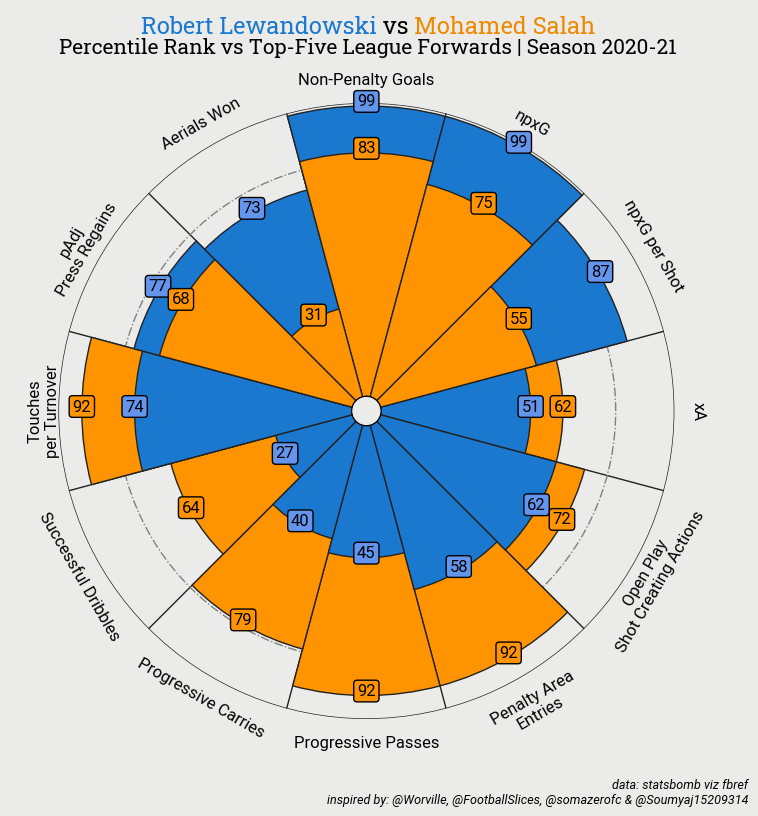

In [3]:
# parameter and values list
# The values are taken from the excellent fbref website (supplied by StatsBomb)
params = [
    "Non-Penalty Goals", "npxG", "npxG per Shot", "xA",
    "Open Play\nShot Creating Actions", "\nPenalty Area\nEntries",
    "Progressive Passes", "Progressive Carries", "Successful Dribbles",
    "\nTouches\nper Turnover", "pAdj\nPress Regains", "Aerials Won"
]
values = [99, 99, 87, 51, 62, 58, 45, 40, 27, 74, 77, 73]    # for Robert Lewandowski
values_2 = [83, 75, 55, 62, 72, 92, 92, 79, 64, 92, 68, 31]  # for Mohamed Salah

# instantiate PyPizza class
baker = PyPizza(
    params=params,                  # list of parameters
    background_color="#EBEBE9",     # background color
    straight_line_color="#222222",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=1,               # linewidth of last circle
    last_circle_color="#222222",    # color of last circle
    other_circle_ls="-.",           # linestyle for other circles
    other_circle_lw=1               # linewidth for other circles
)

# plot pizza
fig, ax = baker.make_pizza(
    values,                     # list of values
    compare_values=values_2,    # comparison values
    figsize=(8, 8),             # adjust figsize according to your need
    kwargs_slices=dict(
        facecolor="#1A78CF", edgecolor="#222222",
        zorder=2, linewidth=1
    ),                          # values to be used when plotting slices
    kwargs_compare=dict(
        facecolor="#FF9300", edgecolor="#222222",
        zorder=2, linewidth=1,
    ),
    kwargs_params=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, va="center"
    ),                          # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="cornflowerblue",
            boxstyle="round,pad=0.2", lw=1
        )
    ),                          # values to be used when adding parameter-values labels
    kwargs_compare_values=dict(
        color="#000000", fontsize=12, fontproperties=font_normal.prop, zorder=3,
        bbox=dict(edgecolor="#000000", facecolor="#FF9300", boxstyle="round,pad=0.2", lw=1)
    ),                          # values to be used when adding parameter-values labels
)

# add title
fig_text(
    0.515, 0.99, "<Robert Lewandowski> vs <Mohamed Salah>", size=17, fig=fig,
    highlight_textprops=[{"color": '#1A78CF'}, {"color": '#EE8900'}],
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add subtitle
fig.text(
    0.515, 0.942,
    "Percentile Rank vs Top-Five League Forwards | Season 2020-21",
    size=15,
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add credits
CREDIT_1 = "data: statsbomb viz fbref"
CREDIT_2 = "inspired by: @Worville, @FootballSlices, @somazerofc & @Soumyaj15209314"

fig.text(
    0.99, 0.005, f"{CREDIT_1}\n{CREDIT_2}", size=9,
    fontproperties=font_italic.prop, color="#000000",
    ha="right"
)

plt.show()

## Adjust Overlapping Values
To adjust overlapping values one can use ``adjust_texts()`` method.
The user have to pass ``params_offset`` list
which will contain bool values denoting which parameter's text is to be adjusted,
an ``offset`` value denoting how much adjustment will be made,
and if the user wants to adjust the comparison-text then can pass
``adj_comp_values=True`` to the ``adjust_texts()`` method. Below is an example code.



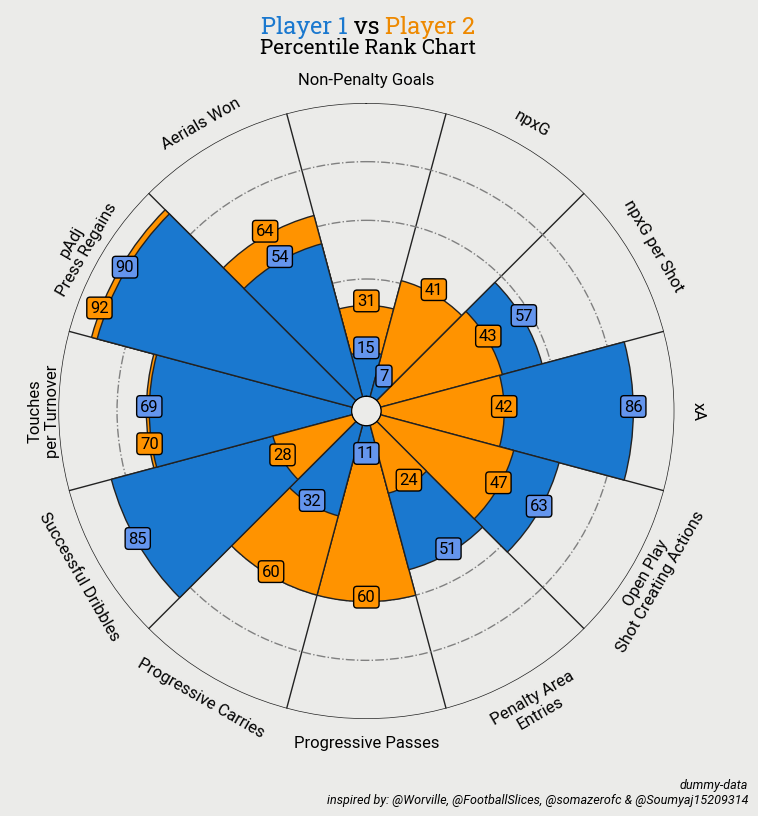

In [4]:
# parameter and values list
params = [
    "Non-Penalty Goals", "npxG", "npxG per Shot", "xA",
    "Open Play\nShot Creating Actions", "\nPenalty Area\nEntries",
    "Progressive Passes", "Progressive Carries", "Successful Dribbles",
    "\nTouches\nper Turnover", "pAdj\nPress Regains", "Aerials Won"
]

# dummy values
values = [15, 7, 57, 86, 63, 51, 11, 32, 85, 69, 90, 54]    # for Player 1
values_2 = [31, 41, 43, 42, 47, 24, 60, 60, 28, 70, 92, 64]  # for Player 2

# pass True in that parameter-index whose values are to be adjusted
# here True values are passed for "\nTouches\nper Turnover" and "pAdj\nPress Regains" params
params_offset = [
    False, False, False, False, False, False,
    False, False, False, True, True, False
]

# instantiate PyPizza class
baker = PyPizza(
    params=params,                  # list of parameters
    background_color="#EBEBE9",     # background color
    straight_line_color="#222222",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=1,               # linewidth of last circle
    last_circle_color="#222222",    # color of last circle
    other_circle_ls="-.",           # linestyle for other circles
    other_circle_lw=1               # linewidth for other circles
)

# plot pizza
fig, ax = baker.make_pizza(
    values,                     # list of values
    compare_values=values_2,    # comparison values
    figsize=(8, 8),             # adjust figsize according to your need
    kwargs_slices=dict(
        facecolor="#1A78CF", edgecolor="#222222",
        zorder=2, linewidth=1
    ),                          # values to be used when plotting slices
    kwargs_compare=dict(
        facecolor="#FF9300", edgecolor="#222222",
        zorder=2, linewidth=1,
    ),
    kwargs_params=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, va="center"
    ),                          # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="cornflowerblue",
            boxstyle="round,pad=0.2", lw=1
        )
    ),                          # values to be used when adding parameter-values labels
    kwargs_compare_values=dict(
        color="#000000", fontsize=12, fontproperties=font_normal.prop, zorder=3,
        bbox=dict(edgecolor="#000000", facecolor="#FF9300", boxstyle="round,pad=0.2", lw=1)
    ),                          # values to be used when adding parameter-values labels
)


# adjust text for comparison-values-text
baker.adjust_texts(params_offset, offset=-0.17, adj_comp_values=True)

# add title
fig_text(
    0.515, 0.99, "<Player 1> vs <Player 2>", size=17, fig=fig,
    highlight_textprops=[{"color": '#1A78CF'}, {"color": '#EE8900'}],
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add subtitle
fig.text(
    0.515, 0.942,
    "Percentile Rank Chart",
    size=15,
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add credits
CREDIT_1 = "dummy-data"
CREDIT_2 = "inspired by: @Worville, @FootballSlices, @somazerofc & @Soumyaj15209314"

fig.text(
    0.99, 0.005, f"{CREDIT_1}\n{CREDIT_2}", size=9,
    fontproperties=font_italic.prop, color="#000000",
    ha="right"
)

plt.show()

## Using Alternative Text Values for Comparison
Sometimes you want to display actual values on the comparison pizza chart
while still using percentiles for the visual representation. The
``alt_text_values`` and ``alt_text_compare_values`` parameters allow you
to specify different values to display on the chart for both players
while keeping the percentile calculations for the slice sizes.



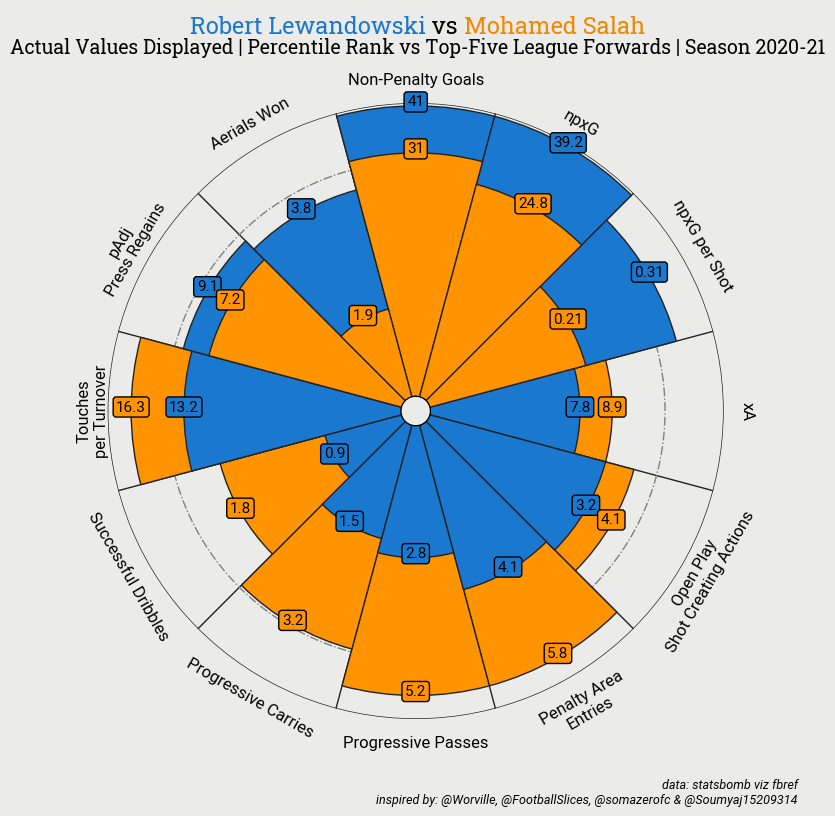

In [5]:
# parameter list
params = [
    "Non-Penalty Goals", "npxG", "npxG per Shot", "xA",
    "Open Play\nShot Creating Actions", "\nPenalty Area\nEntries",
    "Progressive Passes", "Progressive Carries", "Successful Dribbles",
    "\nTouches\nper Turnover", "pAdj\nPress Regains", "Aerials Won"
]

# percentile values for visualization (slice sizes)
lewandowski_percentiles = [99, 99, 87, 51, 62, 58, 45, 40, 27, 74, 77, 73]
salah_percentiles = [83, 75, 55, 62, 72, 92, 92, 79, 64, 92, 68, 31]

# actual raw values to display for Lewandowski
lewandowski_actual = [41, 39.2, 0.31, 7.8, 3.2, 4.1, 2.8, 1.5, 0.9, 13.2, 9.1, 3.8]

# actual raw values to display for Salah
salah_actual = [31, 24.8, 0.21, 8.9, 4.1, 5.8, 5.2, 3.2, 1.8, 16.3, 7.2, 1.9]

# instantiate PyPizza class
baker = PyPizza(
    params=params,                  # list of parameters
    background_color="#EBEBE9",     # background color
    straight_line_color="#222222",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=1,               # linewidth of last circle
    last_circle_color="#222222",    # color of last circle
    other_circle_ls="-.",           # linestyle for other circles
    other_circle_lw=1               # linewidth for other circles
)

# plot pizza with alternative text values for both players
fig, ax = baker.make_pizza(
    lewandowski_percentiles,              # list of percentile values for Player 1
    compare_values=salah_percentiles,     # percentile values for Player 2
    alt_text_values=lewandowski_actual,   # actual values to display for Player 1
    alt_text_compare_values=salah_actual, # actual values to display for Player 2
    figsize=(8, 8),                       # adjust figsize according to your need
    kwargs_slices=dict(
        facecolor="#1A78CF", edgecolor="#222222",
        zorder=2, linewidth=1
    ),                                    # values to be used when plotting slices
    kwargs_compare=dict(
        facecolor="#FF9300", edgecolor="#222222",
        zorder=2, linewidth=1,
    ),
    kwargs_params=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, va="center"
    ),                                    # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=11,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="#1A78CF",
            boxstyle="round,pad=0.2", lw=1
        )
    ),                                    # values to be used when adding parameter-values labels
    kwargs_compare_values=dict(
        color="#000000", fontsize=11, fontproperties=font_normal.prop, zorder=3,
        bbox=dict(edgecolor="#000000", facecolor="#FF9300", boxstyle="round,pad=0.2", lw=1)
    ),                                    # values to be used when adding parameter-values labels
)

# add title
fig_text(
    0.515, 0.99, "<Robert Lewandowski> vs <Mohamed Salah>", size=17, fig=fig,
    highlight_textprops=[{"color": '#1A78CF'}, {"color": '#EE8900'}],
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add subtitle
fig.text(
    0.515, 0.942,
    "Actual Values Displayed | Percentile Rank vs Top-Five League Forwards | Season 2020-21",
    size=14,
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add credits
CREDIT_1 = "data: statsbomb viz fbref"
CREDIT_2 = "inspired by: @Worville, @FootballSlices, @somazerofc & @Soumyaj15209314"

fig.text(
    0.99, 0.005, f"{CREDIT_1}\n{CREDIT_2}", size=9,
    fontproperties=font_italic.prop, color="#000000",
    ha="right"
)

plt.show()

## Interactive Player Comparison
Use the interactive cell below to view a pizza chart for a single player or compare two players side-by-side. 
Input the player's name or list number when prompted.

In [ ]:
import matplotlib.pyplot as plt
from highlight_text import fig_text
from mplsoccer import PyPizza, FontManager
import pandas as pd

# -----------------------------
# 1. Fonts
# -----------------------------
font_normal = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Regular.ttf')
font_italic = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Italic.ttf')
font_bold = FontManager('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/RobotoSlab[wght].ttf')

# -----------------------------
# 2. Load dataset safely
# -----------------------------
df = pd.read_csv("big5_player_stats.csv")
df.columns = df.columns.str.strip()

print("\nColumns found in dataset:")
print(df.columns.tolist())
print("\nPreview:")
print(df.head())

# -----------------------------
# 3. Detect player column safely
# -----------------------------
possible_player_cols = [c for c in df.columns if "player" in c.lower()]

if possible_player_cols:
    player_col = possible_player_cols[0]
else:
    player_col = df.columns[0]

print(f"\nUsing player column: {player_col}")

# -----------------------------
# 4. Build player database
# -----------------------------
players_db = {}

for _, row in df.iterrows():
    name = row[player_col]

    if pd.isna(name):
        continue

    players_db[name] = {
        "percentiles": [
            row.get("Gls", 0),
            row.get("npxG", 0),
            row.get("npxG per Shot", 0),
            row.get("xA", 0),
            row.get("Ast", 0),
            row.get("Progressive Passes", 0),
            row.get("Progressive Carries", 0),
            row.get("Successful Dribbles", 0),
            row.get("Aerials Won", 0),
            row.get("CrdY", 0),
            row.get("CrdR", 0),
            row.get("MP", 0)
        ],
        "actual": [
            row.get("Gls", 0),
            row.get("npxG", 0),
            row.get("npxG per Shot", 0),
            row.get("xA", 0),
            row.get("Ast", 0),
            row.get("Progressive Passes", 0),
            row.get("Progressive Carries", 0),
            row.get("Successful Dribbles", 0),
            row.get("Aerials Won", 0),
            row.get("CrdY", 0),
            row.get("CrdR", 0),
            row.get("MP", 0)
        ],
        "color": "#1f77b4"
    }

# -----------------------------
# 5. Player list
# -----------------------------
player_names = list(players_db.keys())

print("\nTop players:")
for i, name in enumerate(player_names[:20], 1):
    print(f"{i}. {name}")

print("-" * 40)

# -----------------------------
# 6. Safe player search
# -----------------------------
def find_player(query):
    query = str(query).strip().lower()
    for name in players_db:
        if query in name.lower():
            return name
    return None

def get_player(prompt):
    user_input = input(prompt).strip()

    if not user_input:
        return None

    # Try number input
    try:
        idx = int(user_input) - 1
        if 0 <= idx < len(player_names):
            return player_names[idx]
    except:
        pass

    # Try text match
    return find_player(user_input)

# -----------------------------
# 7. Player 1 (REQUIRED)
# -----------------------------
p1_name = get_player("Enter Player 1 name or number: ")

if not p1_name:
    print("❌ Player 1 not found. Exiting.")
    exit()

# -----------------------------
# 8. Player 2 (optional)
# -----------------------------
p2_name = get_player("Enter Player 2 name (optional): ")

if p2_name == p1_name:
    p2_name = None

# -----------------------------
# 9. Pizza setup
# -----------------------------
params = [
    "Non-Penalty Goals", "npxG", "npxG per Shot", "xA",
    "Open Play Shot Creating Actions", "Penalty Area Entries",
    "Progressive Passes", "Progressive Carries", "Successful Dribbles",
    "Touches per Turnover", "pAdj Press Regains", "Aerials Won"
]

baker = PyPizza(
    params=params,
    background_color="#EBEBE9",
    straight_line_color="#222222",
    straight_line_lw=1,
    last_circle_lw=1,
    last_circle_color="#222222",
    other_circle_ls="-.",
    other_circle_lw=1
)

p1_data = players_db[p1_name]

# -----------------------------
# 10. Plot
# -----------------------------
if p2_name:

    p2_data = players_db[p2_name]

    fig, ax = baker.make_pizza(
        p1_data["percentiles"],
        compare_values=p2_data["percentiles"],
        alt_text_values=p1_data["actual"],
        alt_text_compare_values=p2_data["actual"],
        figsize=(8, 8),
        kwargs_slices=dict(facecolor=p1_data["color"], edgecolor="#222222"),
        kwargs_compare=dict(facecolor="#ff7f0e", edgecolor="#222222"),
        kwargs_params=dict(fontproperties=font_normal.prop, fontsize=11),
        kwargs_values=dict(fontproperties=font_normal.prop, fontsize=10),
        kwargs_compare_values=dict(fontproperties=font_normal.prop, fontsize=10)
    )

    fig_text(
        0.5, 0.98,
        f"<{p1_name}> vs <{p2_name}>",
        ha="center",
        fontproperties=font_bold.prop,
        highlight_textprops=[{"color": p1_data["color"]}, {"color": "#ff7f0e"}],
        fig=fig
    )

else:

    fig, ax = baker.make_pizza(
        p1_data["percentiles"],
        alt_text_values=p1_data["actual"],
        figsize=(8, 8),
        kwargs_slices=dict(facecolor=p1_data["color"], edgecolor="#222222"),
        kwargs_params=dict(fontproperties=font_normal.prop, fontsize=11),
        kwargs_values=dict(fontproperties=font_normal.prop, fontsize=10)
    )

    fig_text(
        0.5, 0.98,
        f"{p1_name}",
        ha="center",
        fontproperties=font_bold.prop,
        highlight_textprops=[{"color": p1_data["color"]}],
        fig=fig
    )

# -----------------------------
# 11. Footer
# -----------------------------
fig.text(
    0.5, 0.94,
    "FBref Stats | PyPizza Visualization",
    ha="center",
    fontproperties=font_bold.prop
)

fig.text(
    0.99, 0.01,
    "data: FBref | viz: mplsoccer",
    ha="right",
    fontsize=8,
    fontproperties=font_italic.prop
)

plt.show()


Columns found in dataset:
['Unnamed: 0_level_0', 'Unnamed: 1_level_0', 'Unnamed: 2_level_0', 'Unnamed: 3_level_0', 'Unnamed: 4_level_0', 'Unnamed: 5_level_0', 'Unnamed: 6_level_0', 'Unnamed: 7_level_0', 'Playing Time', 'Playing Time.1', 'Playing Time.2', 'Playing Time.3', 'Performance', 'Performance.1', 'Performance.2', 'Performance.3', 'Performance.4', 'Performance.5', 'Performance.6', 'Performance.7', 'Per 90 Minutes', 'Per 90 Minutes.1', 'Per 90 Minutes.2', 'Per 90 Minutes.3', 'Per 90 Minutes.4', 'Unnamed: 25_level_0']

Preview:
  Unnamed: 0_level_0   Unnamed: 1_level_0 Unnamed: 2_level_0  \
0                 Rk               Player             Nation   
1                  1     Brenden Aaronson             us USA   
2                  2         Jerome Abbey            eng ENG   
3                  3          Zach Abbott            eng ENG   
4                  4  Jones El-Abdellaoui             ma MAR   

  Unnamed: 3_level_0 Unnamed: 4_level_0  Unnamed: 5_level_0  \
0            

KeyError: None

: 